<a href="https://colab.research.google.com/github/MiguelAngeloTr/Aprendizaje_Automatico/blob/main/Entrega_6/Clasificacion_de_celulas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Paso 1: Subir archivo desde tu computadora
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

#***SECCIÓN 1: EXTRACCIÓN DE CARACTERÍSTICAS, EDA y PCA***


#Carga de datos

In [6]:
def cargar_dataset_y_features(ruta_base, dicc_clases):
    X = []
    y = []
    paths = []

    for carpeta, etiqueta in dicc_clases.items():
        carpeta_path = os.path.join(ruta_base, carpeta)

        for archivo in os.listdir(carpeta_path):
            img_path = os.path.join(carpeta_path, archivo)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (128,128))

            # Extraer 3 características
            ent, cont, dens_b = extraer_caracteristicas(img)

            X.append([ent, cont, dens_b])
            y.append(etiqueta)
            paths.append(img_path)

    return np.array(X), np.array(y), paths


#Extraccion de caracteristicas
>Aunque existen múltiples tipos de características que pueden extraerse de una imagen —como métricas basadas en tamaño, textura, color o incluso en el dominio espacio-frecuencia. Para este trabajo se seleccionaron tres características texturales: entropía, contraste GLCM y densidad de bordes. Esta elección se fundamenta en la naturaleza del problema, ya que las células Basófilas y Eritroblastos presentan diferencias marcadas principalmente en su textura interna, granularidad y complejidad estructural más que en su tamaño o color. Las métricas de textura capturan de manera directa estas variaciones morfológicas relevantes y demostraron ser adecuadas para la diferenciación, como lo confirmó el análisis PCA, en el que las dos primeras componentes explicaron más del 94% de la varianza total. Por lo tanto, el uso de estas tres características texturales es pertinente, suficiente y coherente con las particularidades del dataset propuesto.

In [46]:
import os
import cv2
import numpy as np
from skimage.measure import shannon_entropy
from skimage.feature import graycomatrix, graycoprops

def extraer_caracteristicas(img):
    """
    Extrae 3 características de textura:
    1. Entropía
    2. Contraste (GLCM)
    3. Densidad de bordes (Canny)
    """

    # 1. ENTROPÍA
    entropia = shannon_entropy(img)

    # 2. CONTRASTE GLCM
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256,
                        symmetric=True, normed=True)
    contraste = graycoprops(glcm, 'contrast')[0][0]

    # 3. DENSIDAD DE BORDES
    edges = cv2.Canny(img, 100, 200)
    dens_bordes = np.mean(edges > 0)

    return entropia, contraste, dens_bordes


In [44]:

!ls celulas_descomprimidas/Inference


Basofilos_inference  Eritoblastos_inference


In [47]:
import zipfile
import os

# Define the path for the unzipped files
unzip_path = "celulas_descomprimidas"

# Create the directory if it doesn't exist
if not os.path.exists(unzip_path):
    os.makedirs(unzip_path)

# Unzip the training data if not already unzipped
zip_file_path_train = "BaseDatos_CelulasSangre_Train.zip"
if os.path.exists(zip_file_path_train):
    with zipfile.ZipFile(zip_file_path_train, 'r') as zip_ref:
        zip_ref.extractall(unzip_path)
    print(f"'{zip_file_path_train}' unzipped to '{unzip_path}'")
else:
    print(f"Warning: '{zip_file_path_train}' not found. Ensure it's uploaded.")

# Unzip the test data if not already unzipped
zip_file_path_test = "BaseDatos_CelulasSangre_Test.zip"
if os.path.exists(zip_file_path_test):
    with zipfile.ZipFile(zip_file_path_test, 'r') as zip_ref:
        zip_ref.extractall(unzip_path)
    print(f"'{zip_file_path_test}' unzipped to '{unzip_path}'")
else:
    print(f"Warning: '{zip_file_path_test}' not found. Ensure it's uploaded.")

clases_train = {
    "Basofilos_train": 0,
    "Eritroblasto_train": 1
}

X_train, y_train, paths_train = cargar_dataset_y_features(unzip_path, clases_train)

print(X_train.shape)
print(y_train.shape)


clases_test = {
    "Basofilos_inference": 0,
    "Eritoblastos_inference": 1
}

X_test, y_test, paths_test = cargar_dataset_y_features(os.path.join(unzip_path, "Inference"), clases_test)

print(X_test.shape)
print(y_test.shape)

'BaseDatos_CelulasSangre_Train.zip' unzipped to 'celulas_descomprimidas'
'BaseDatos_CelulasSangre_Test.zip' unzipped to 'celulas_descomprimidas'
(120, 3)
(120,)
(10, 3)
(10,)


In [58]:
import pandas as pd

celulas = pd.DataFrame({
    "entropia": X_train[:,0],
    "contraste": X_train[:,1],
    "densidad_bordes": X_train[:,2],
    "clase": y_train
})



In [61]:
celulas.shape

(120, 4)

In [65]:
#Exportar CSV

celulas.to_csv("dataset_120x4_train.csv", index=False)


#EDA

In [56]:
import pandas as pd

celulas= pd.read_csv("dataset_120x4_train.csv")
celulas.head()


,entropia,contraste,densidad_bordes,clase
0,5.759945,176.721088,0.107971,0
1,5.561098,146.241265,0.075928,0
2,5.769350,139.358883,0.085632,0
3,5.930780,239.089505,0.133911,0
4,5.652235,195.638841,0.092468,0


<Axes: title={'center': 'Distribución de clases'}, xlabel='clase'>

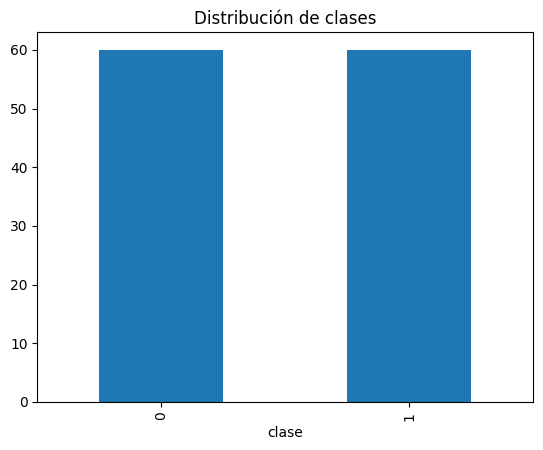

In [57]:
celulas["clase"].value_counts().plot(kind="bar", title="Distribución de clases")


In [15]:
celulas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   entropia         120 non-null    float64
 1   contraste        120 non-null    float64
 2   densidad_bordes  120 non-null    float64
 3   clase            120 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 3.9 KB


In [63]:
celulas.describe()


,entropia,contraste,densidad_bordes,clase
count,120.000000,120.000000,120.000000,120.000000
mean,5.501136,123.333297,0.075287,0.500000
std,0.470321,76.023334,0.032570,0.502096
min,4.166434,32.933317,0.010437,0.000000
25%,5.180659,55.729654,0.057190,0.000000
50%,5.624037,92.209400,0.082886,0.500000
75%,5.824610,187.102162,0.097214,1.000000
max,6.419426,331.744218,0.134460,1.000000


In [64]:
#Estadisticos descriptivos por cada clase

celulas.groupby("clase")[["entropia","contraste","densidad_bordes"]].mean()



,entropia,contraste,densidad_bordes
clase,,,
0,5.727595,191.270986,0.098323
1,5.274676,55.395608,0.052251


Histogramas por variables

Text(0.5, 1.0, 'Distribución de Entropía')

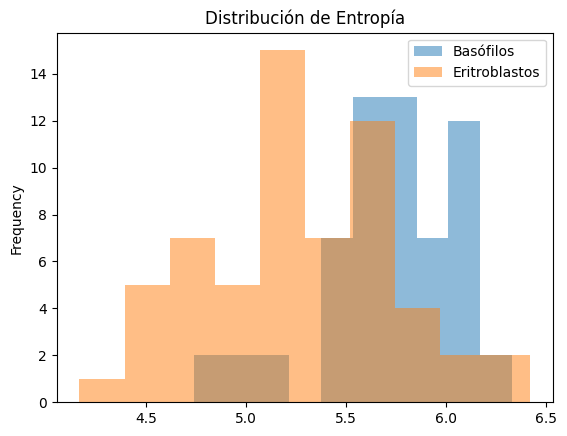

In [18]:
#Entropia
celulas[celulas["clase"]==0]["entropia"].plot(kind="hist", alpha=0.5, label="Basófilos")
celulas[celulas["clase"]==1]["entropia"].plot(kind="hist", alpha=0.5, label="Eritroblastos")
plt.legend(); plt.title("Distribución de Entropía")


Text(0.5, 1.0, 'Distribución de Contraste')

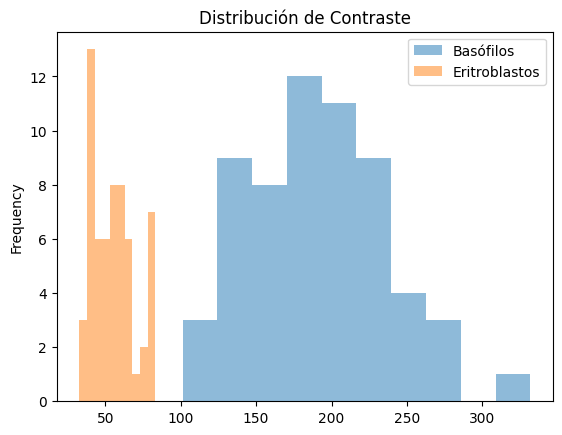

In [19]:
#Contraste

celulas[celulas["clase"]==0]["contraste"].plot(kind="hist", alpha=0.5, label="Basófilos")
celulas[celulas["clase"]==1]["contraste"].plot(kind="hist", alpha=0.5, label="Eritroblastos")
plt.legend(); plt.title("Distribución de Contraste")


Text(0.5, 1.0, 'Distribución de Densidad de Bordes')

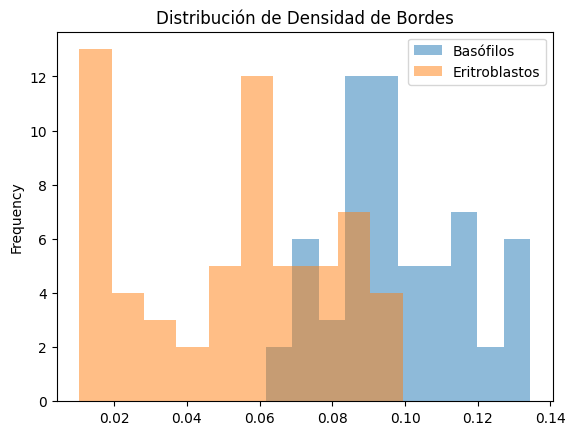

In [20]:
#Densidad de bordes

celulas[celulas["clase"]==0]["densidad_bordes"].plot(kind="hist", alpha=0.5, label="Basófilos")
celulas[celulas["clase"]==1]["densidad_bordes"].plot(kind="hist", alpha=0.5, label="Eritroblastos")
plt.legend(); plt.title("Distribución de Densidad de Bordes")


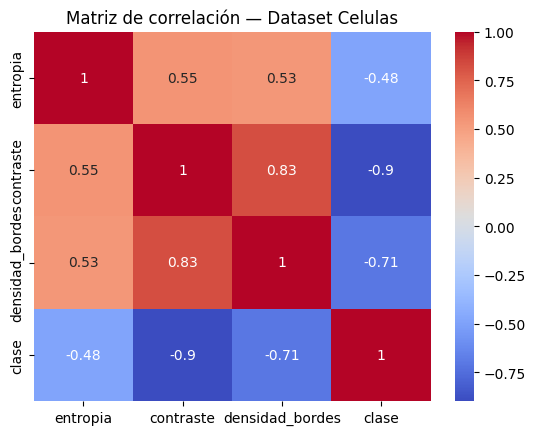

In [21]:
#Matriz de correlacion
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(celulas.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación — Dataset Celulas")
plt.show()


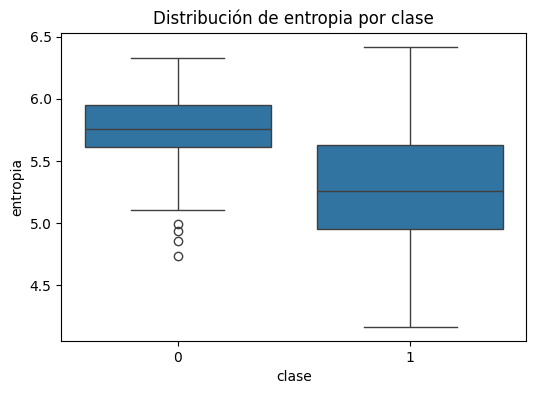

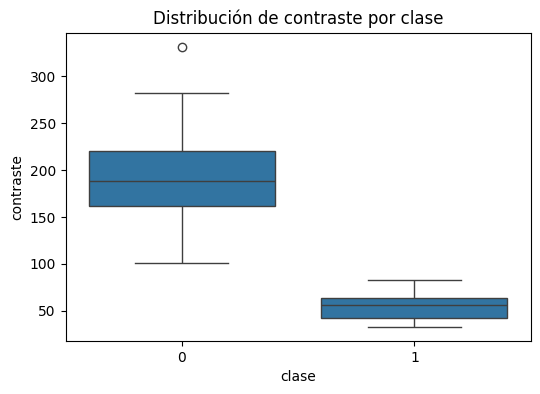

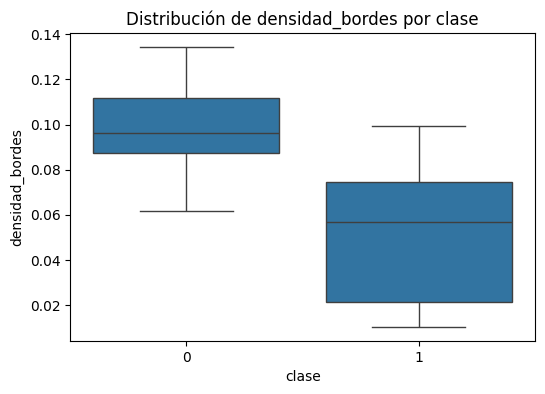

In [22]:
for v in ["entropia","contraste","densidad_bordes"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="clase", y=v, data=celulas)
    plt.title(f"Distribución de {v} por clase")
    plt.show()


#PCA



In [23]:
import pandas as pd

# Ya tienes cargado:
# celulas = pd.read_csv("dataset_120x4_train.csv")

X = celulas[["entropia", "contraste", "densidad_bordes"]]
y = celulas["clase"]


In [24]:

#1 Estandandarizacion de los datos

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




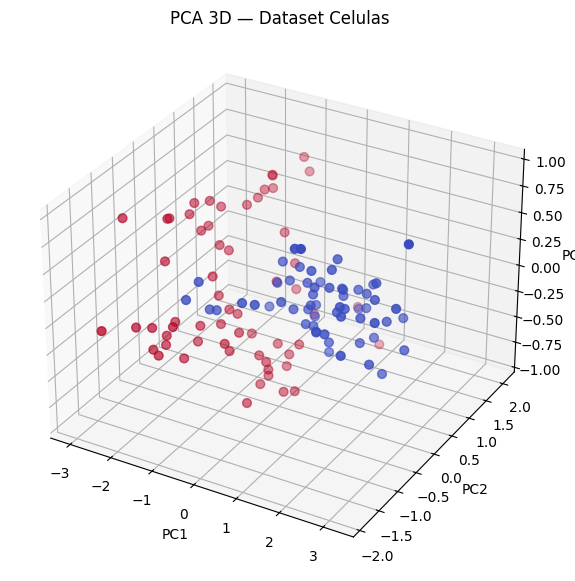

In [30]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y, cmap="coolwarm", s=40)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("PCA 3D — Dataset Celulas")
plt.show()



In [33]:


var_exp = pca3.explained_variance_ratio_
cum_var_exp = var_exp.cumsum()

print("Varianza individual:", var_exp)
print("Varianza acumulada:", cum_var_exp)


Varianza individual: [0.76183326 0.1813747  0.05679203]
Varianza acumulada: [0.76183326 0.94320797 1.        ]


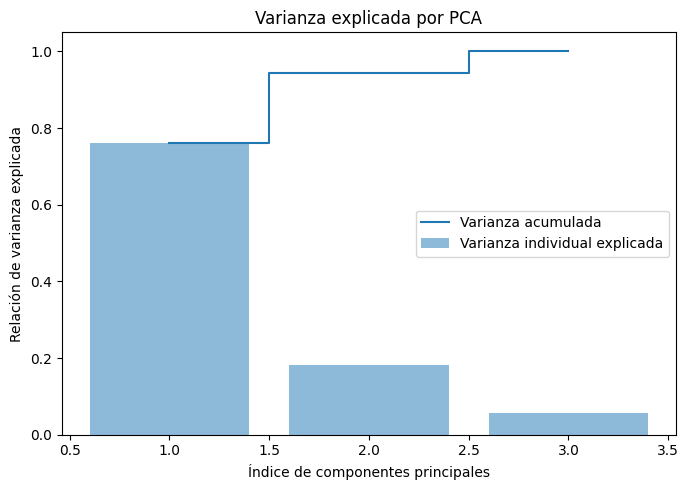

In [34]:
import matplotlib.pyplot as plt

n = len(var_exp)

plt.figure(figsize=(7,5))

# Barras de varianza individual
plt.bar(range(1, n + 1), var_exp, alpha=0.5, align='center',
        label='Varianza individual explicada')

# Línea de varianza acumulada
plt.step(range(1, n + 1), cum_var_exp, where='mid',
         label='Varianza acumulada')

plt.ylabel('Relación de varianza explicada')
plt.xlabel('Índice de componentes principales')
plt.title('Varianza explicada por PCA')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [35]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2','PC3'],
    index=["entropia","contraste","densidad_bordes"]
)

loadings


,PC1,PC2,PC3
entropia,0.511784,0.858756,-0.024803
contraste,0.609504,-0.342590,0.714938
densidad_bordes,0.605460,-0.381012,-0.698747


Interpretacion:

La primera componente principal (PC1), que explica el 76.18% de la varianza, presenta cargas altas y positivas en las tres características (entropía, contraste y densidad de bordes), lo que indica que representa un eje de complejidad textural global. Las células con alto PC1 son más granuladas, diversas en intensidad y con más bordes detectables, características asociadas a los Basófilos; mientras que valores bajos reflejan células más lisas y homogéneas, como los Eritroblastos. La segunda componente (PC2), dominada por la entropía, captura variaciones específicas de complejidad que no se alinean directamente con el contraste o la presencia de bordes. Finalmente, la tercera componente (PC3) refleja diferencias opuestas entre contraste y densidad de bordes, explicando solo un 5.67% de la varianza total.

***Implemente la aplicación de la Técnica Análisis de Componentes Principales (PCA) sobre su dataset y confirme si fuera beneficioso o no usar menos características que las 3 propuestas por usted mismo en el ítem 1.***
>Respuesta :
La aplicación del PCA demuestra que reducir el número de características de 3 a 2 es completamente viable y beneficioso, ya que las dos primeras componentes principales conservan más del 94% de la variabilidad del dataset. Por tanto, es posible trabajar con dos características transformadas (PC1 y PC2) sin perder información relevante para la clasificación celular.

#***SECCIÓN 2: CLASIFICACIÓN UTILIZANDO APRENDIZAJE SUPERVISADO***


In [66]:
import os
import cv2
import pandas as pd
from sklearn.preprocessing import StandardScaler

# =========================
# 1. TRAIN
# =========================
celulas = pd.read_csv("dataset_120x4_train.csv")
X_train = celulas[["entropia","contraste","densidad_bordes"]].values
y_train = celulas["clase"].values

# =========================
# 2. TEST - Extraer características desde IMÁGENES
# =========================

ruta_test = "celulas_descomprimidas/Inference"

clases_test = {
    "Basofilos_inference": 0,
    "Eritoblastos_inference": 1
}

caracteristicas_test = []
clases_test_list = []

for carpeta, etiqueta in clases_test.items():
    carpeta_path = os.path.join(ruta_test, carpeta)
    for archivo in os.listdir(carpeta_path):
        img = cv2.imread(os.path.join(carpeta_path, archivo), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128,128))

        ent, cont, dens = extraer_caracteristicas(img)

        caracteristicas_test.append([ent, cont, dens])
        clases_test_list.append(etiqueta)

# Crear DataFrame del test
celulas_test_df = pd.DataFrame(caracteristicas_test,
                               columns=["entropia","contraste","densidad_bordes"])
celulas_test_df["clase"] = clases_test_list

# Guardar CSV del test
celulas_test_df.to_csv("dataset_10x4_test.csv", index=False)

# =========================
# 3. Cargar TEST desde CSV
# =========================

celulas_test = pd.read_csv("dataset_10x4_test.csv")
X_test = celulas_test[["entropia","contraste","densidad_bordes"]].values
y_test = celulas_test["clase"].values

# =========================
# 4. ESCALAR TRAIN Y TEST
# =========================

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


print("X_train_std shape:", X_train_std.shape)
print("y_train shape:", y_train.shape)

print("X_test_std shape:", X_test_std.shape)
print("y_test shape:", y_test.shape)



X_train_std shape: (120, 3)
y_train shape: (120,)
X_test_std shape: (10, 3)
y_test shape: (10,)


MODELO 1 KNN

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_std, y_train)

y_pred_knn = knn.predict(X_test_std)
acc_knn = accuracy_score(y_test, y_pred_knn)

print("Exactitud KNN:", acc_knn)


Exactitud KNN: 1.0


MODELO 2 SVM

In [68]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=1, gamma="scale")
svm.fit(X_train_std, y_train)

y_pred_svm = svm.predict(X_test_std)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("Exactitud SVM:", acc_svm)


Exactitud SVM: 1.0


MODELO 3 DESICION TREE

In [69]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train_std, y_train)

y_pred_tree = tree.predict(X_test_std)
acc_tree = accuracy_score(y_test, y_pred_tree)

print("Exactitud Árbol de Decisión:", acc_tree)


Exactitud Árbol de Decisión: 1.0


In [70]:
print("Resultados finales:")
print("KNN:", acc_knn)
print("SVM:", acc_svm)
print("Árbol:", acc_tree)


Resultados finales:
KNN: 1.0
SVM: 1.0
Árbol: 1.0


METRICAS Y MATRICES DE CONFUSION


================ KNN ================
Exactitud: 1.0


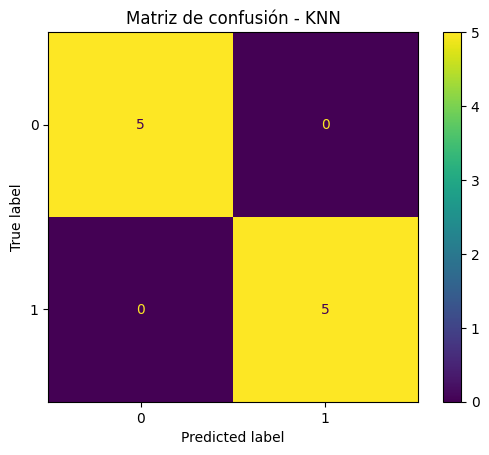

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


================ SVM ================
Exactitud: 1.0


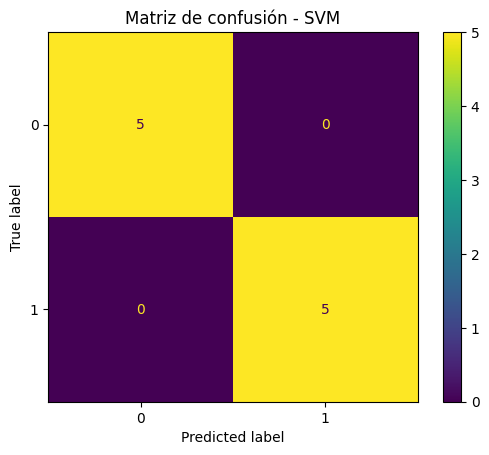

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


================ Árbol de desición ================
Exactitud: 1.0


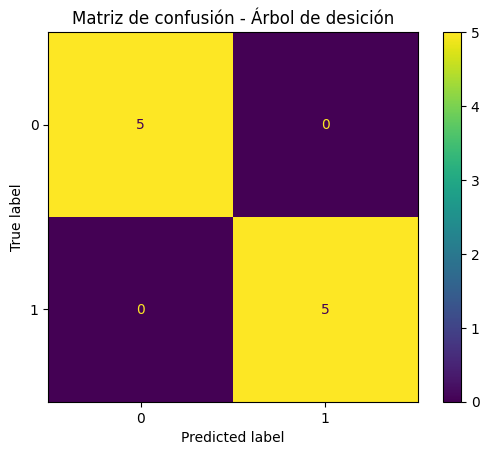

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report

modelos = {
    "KNN": knn,
    "SVM": svm,
    "Árbol de desición": tree
}

for nombre, modelo in modelos.items():
    print(f"\n================ {nombre} ================")

    y_pred = modelo.predict(X_test_std)

    # Exactitud
    acc = accuracy_score(y_test, y_pred)
    print("Exactitud:", acc)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    # Reporte de métricas
    print("Reporte de clasificación:")
    print(classification_report(y_test, y_pred))


SUPERFICIES DE SEPARACION CON TEST Y TRAIN

In [74]:
from sklearn.decomposition import PCA

# Reducimos a 2D para poder dibujar regiones
pca_vis = PCA(n_components=2)
X_train_pca = pca_vis.fit_transform(X_train_std)
X_test_pca = pca_vis.transform(X_test_std)


#Funcion para graficar test y train

from matplotlib.colors import ListedColormap
import numpy as np

def plot_decision_regions_train_test(X_train, y_train, X_test, y_test, classifier, title, resolution=0.02):
    # Unimos train + test solo para definir el grid
    X_all = np.vstack((X_train, X_test))
    x1_min, x1_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
    x2_min, x2_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

    plt.figure(figsize=(7,5))
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap_light)

    # Puntos de TRAIN
    plt.scatter(X_train[:,0], X_train[:,1],
                c=y_train, cmap=cmap_bold,
                marker='o', edgecolor='k', label='Train')

    # Puntos de TEST
    plt.scatter(X_test[:,0], X_test[:,1],
                c=y_test, cmap=cmap_bold,
                marker='s', edgecolor='k', label='Test')

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


Modelos para visualización sobre PCA (PC1, PC2)

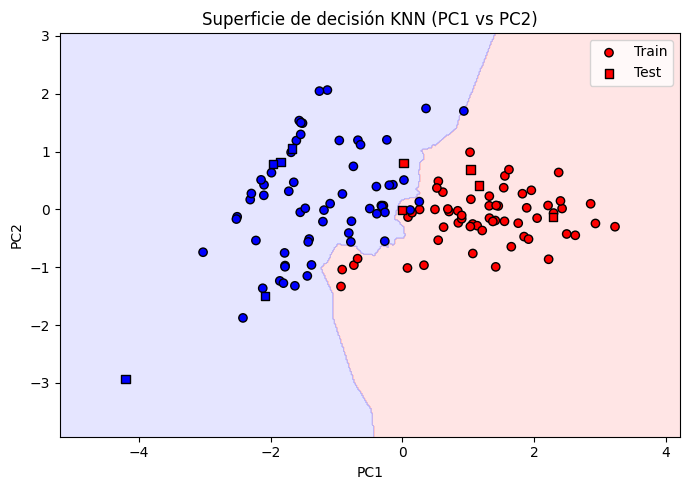

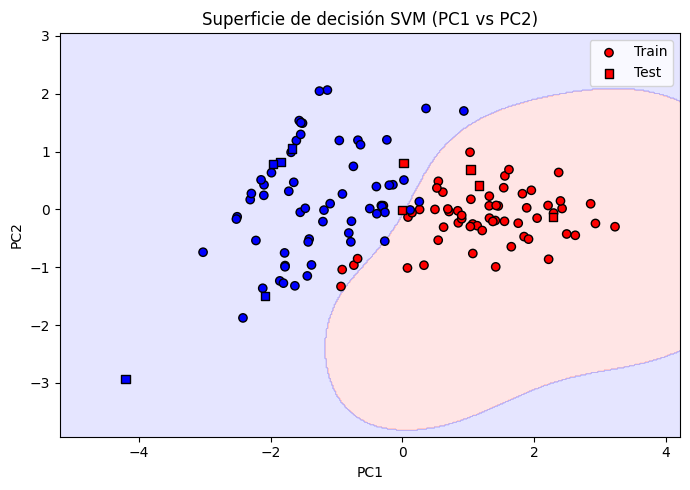

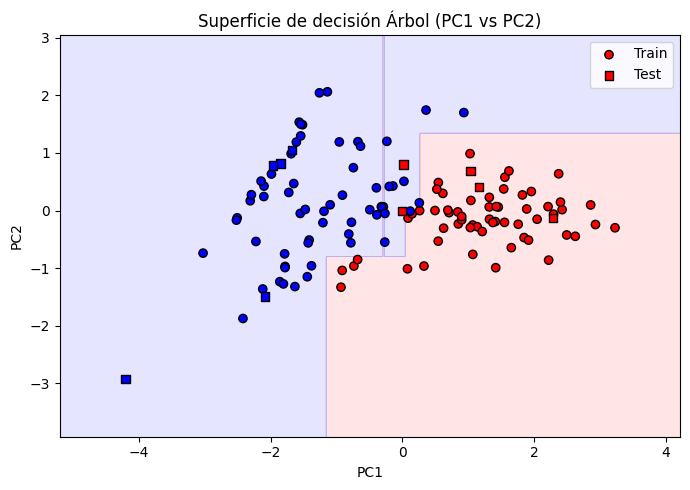

In [75]:

knn_vis = KNeighborsClassifier(n_neighbors=5).fit(X_train_pca, y_train)
svm_vis = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=0).fit(X_train_pca, y_train)
tree_vis = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_train_pca, y_train)

plot_decision_regions_train_test(X_train_pca, y_train, X_test_pca, y_test, knn_vis,
                                 "Superficie de decisión KNN (PC1 vs PC2)")
plot_decision_regions_train_test(X_train_pca, y_train, X_test_pca, y_test, svm_vis,
                                 "Superficie de decisión SVM (PC1 vs PC2)")
plot_decision_regions_train_test(X_train_pca, y_train, X_test_pca, y_test, tree_vis,
                                 "Superficie de decisión Árbol (PC1 vs PC2)")


CURVAS ROC PARA CADA MODELO

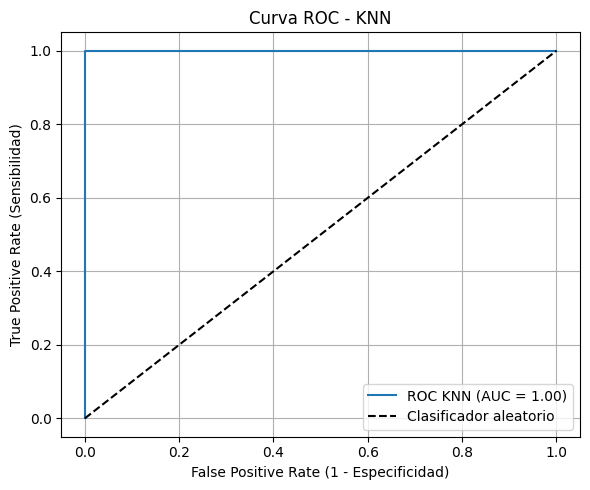

AUC KNN: 1.000


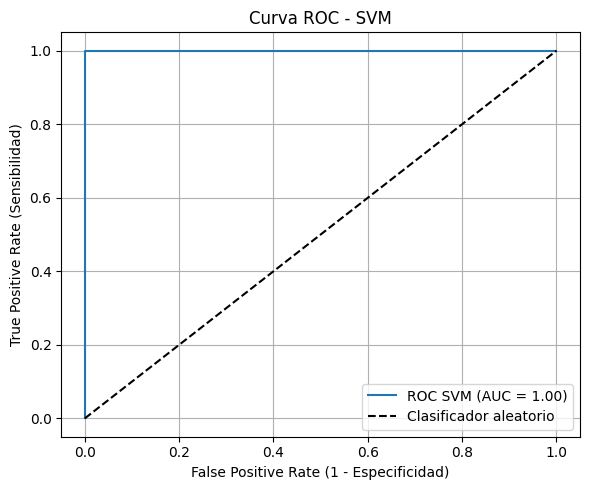

AUC SVM: 1.000


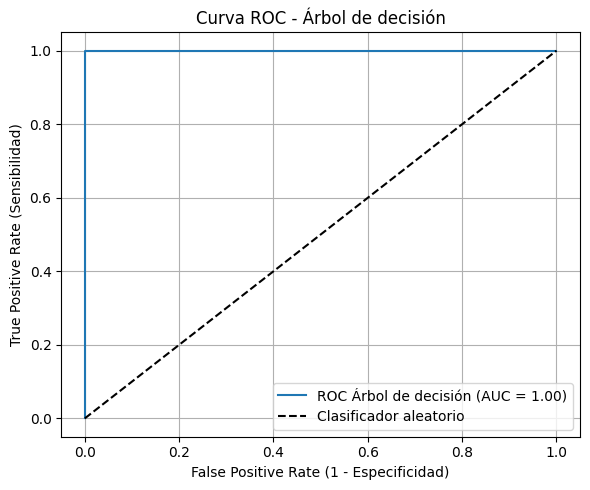

AUC Árbol de decisión: 1.000


In [76]:
from sklearn.metrics import roc_curve, auc

def plot_roc_model(modelo, X_test, y_test, nombre):
    # Para binario 0/1, prob de clase 1
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)[:,1]
    else:
        # SVM sin predict_proba → usamos decision_function (pero ya activamos probability=True)
        y_score = modelo.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC {nombre} (AUC = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], 'k--', label='Clasificador aleatorio')
    plt.xlabel('False Positive Rate (1 - Especificidad)')
    plt.ylabel('True Positive Rate (Sensibilidad)')
    plt.title(f'Curva ROC - {nombre}')
    plt.legend(loc='lower right')
    plt.grid()
    plt.tight_layout()
    plt.show()

    print(f"AUC {nombre}: {roc_auc:.3f}")

# Usamos los modelos entrenados en las 3 características (X_test_std)
plot_roc_model(knn, X_test_std, y_test, "KNN")
plot_roc_model(svm, X_test_std, y_test, "SVM")
plot_roc_model(tree, X_test_std, y_test, "Árbol de decisión")


>La curva ROC obtenida para el clasificador SVM muestra una alta sensibilidad y especificidad, con un área bajo la curva (AUC) cercana a 1, lo que indica un excelente desempeño discriminando entre Basófilos y Eritroblastos. El hecho de que la curva se despegue notablemente de la diagonal del clasificador aleatorio evidencia que el modelo es capaz de asignar puntuaciones de probabilidad coherentes con la verdadera clase de las muestras. Resultados similares se observaron para KNN y Árbol de decisión, lo que es consistente con la exactitud del 100% obtenida en el conjunto de test y confirma que las características de textura seleccionadas son altamente informativas para esta tarea de clasificación.

#FUNCION DE SUBIDA DE IMAGENES

In [77]:
import cv2
import numpy as np
from skimage.measure import shannon_entropy
from skimage.feature import graycomatrix, graycoprops

# --- función ya existente ---
def extraer_caracteristicas(img):
    entropia = shannon_entropy(img)
    glcm = graycomatrix(img, distances=[1], angles=[0],
                        levels=256, symmetric=True, normed=True)
    contraste = graycoprops(glcm, 'contrast')[0][0]
    edges = cv2.Canny(img, 100, 200)
    dens = np.mean(edges > 0)
    return entropia, contraste, dens

def predecir_imagen_nueva(ruta_imagen, scaler, modelo):
    """
    Clasifica una imagen nueva de Basófilo o Eritroblasto.

    Parámetros:
        ruta_imagen: str - path de la imagen nueva
        scaler: StandardScaler entrenado
        modelo: modelo final (SVM)
    """
    # 1. Cargar imagen
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: No se pudo cargar la imagen.")
        return

    # 2. Preprocesamiento
    img = cv2.resize(img, (128,128))

    # 3. Extraer características
    ent, cont, dens = extraer_caracteristicas(img)
    vector = np.array([[ent, cont, dens]])

    # 4. Escalar usando scaler del entrenamiento
    vector_std = scaler.transform(vector)

    # 5. Predecir con el modelo
    pred = modelo.predict(vector_std)[0]

    # 6. Interpretar resultado
    if pred == 0:
        print("La imagen cargada corresponde a un **BASÓFILO**.")
    else:
        print("La imagen cargada corresponde a un **ERITROBLASTO**.")


In [79]:
predecir_imagen_nueva("ERB_153470.jpg", scaler, svm)


La imagen cargada corresponde a un **ERITROBLASTO**.
